# NYC Taxi Trip Duration — Exploratory Data Analysis

**Goal:** Understand the cleaned dataset visually before building any model.
We load one month of cleaned data (Jan 2026) and explore its structure, distributions, and relationships.

**Data:** Yellow taxi trips, January 2026 — cleaned by `src/data/cleaner.py`

## Section 1 — Overview

Load the data and confirm it looks right before plotting anything.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

# Consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load cleaned data
DATA_PATH = Path('../data/cleaned/yellow_tripdata_2026-01_cleaned.parquet')
df = pd.read_parquet(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn names and types:')
print(df.dtypes.to_string())
print(f'\nFirst 3 rows:')
df.head(3)

Shape: 2,687,584 rows × 20 columns

Column names and types:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                    int8
trip_distance                   float64
RatecodeID                         int8
store_and_fwd_flag               object
PULocationID                      int16
DOLocationID                      int16
payment_type                       int8
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
duration_sec                    float64

First 3 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,duration_sec
0,2,2026-01-01 00:57:55,2026-01-01 01:17:43,1,1.72,1,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,1188.0
1,1,2026-01-01 00:03:00,2026-01-01 00:09:36,1,1.80,1,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,396.0
2,1,2026-01-01 00:17:06,2026-01-01 00:35:01,1,4.70,1,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,1075.0


## Section 2 — Target Analysis

**`duration_sec` is what we're predicting.** Before building any model, we need to understand its shape:
- Is it symmetric or skewed?
- What's the typical trip duration?
- Are there outliers that could hurt model training?

**Why log transform matters:** Most ML models assume the target is roughly symmetric (bell-shaped).
If the target is heavily right-skewed (long tail on the right), the model spends too much effort
on rare extreme values and does poorly on typical cases.
Taking `log(duration)` compresses the tail and makes it more symmetric.

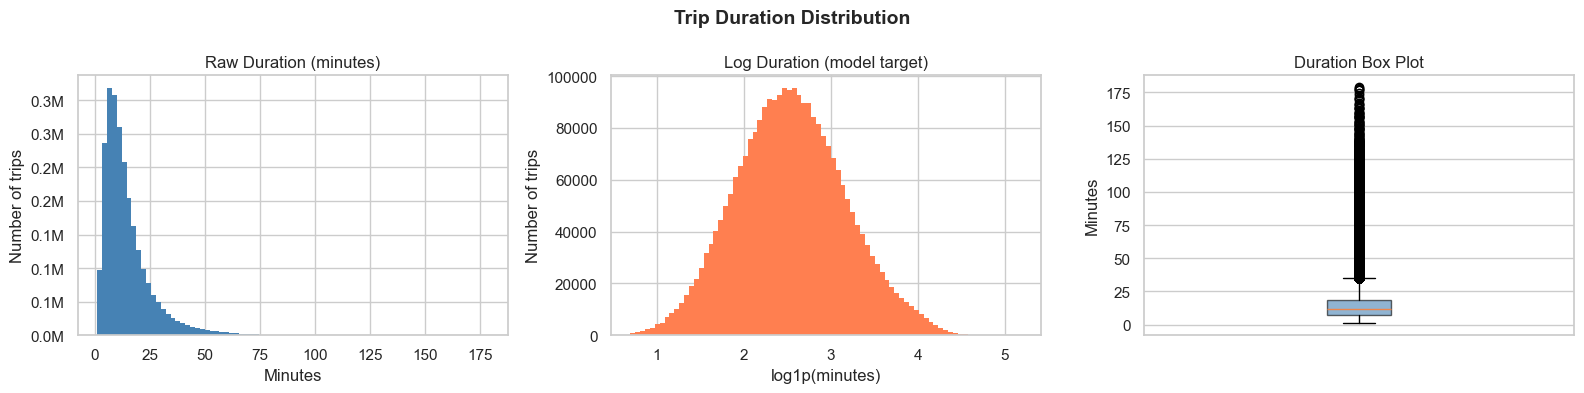

Duration Statistics (minutes):
count    2687584.0
mean          14.6
std           11.0
min            1.0
25%            7.2
50%           11.5
75%           18.3
max          178.8

Skewness: 2.16  (0 = symmetric, >1 = right-skewed)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Trip Duration Distribution', fontsize=14, fontweight='bold')

duration_min = df['duration_sec'] / 60

# Raw duration in minutes
axes[0].hist(duration_min, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Duration (minutes)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Number of trips')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Log-transformed — this is what the model will actually predict
axes[1].hist(np.log1p(duration_min), bins=80, color='coral', edgecolor='none')
axes[1].set_title('Log Duration (model target)')
axes[1].set_xlabel('log1p(minutes)')
axes[1].set_ylabel('Number of trips')

# Box plot to show outliers
axes[2].boxplot(duration_min, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Duration Box Plot')
axes[2].set_ylabel('Minutes')
axes[2].set_xticks([])

plt.tight_layout()
plt.show()

print('Duration Statistics (minutes):')
print(duration_min.describe().round(1).to_string())
print(f'\nSkewness: {duration_min.skew():.2f}  (0 = symmetric, >1 = right-skewed)')

## Section 3 — Missing Values

Even after cleaning, it's worth confirming nulls are gone.
A heatmap makes this instant to read — dark = nulls present, light = clean.

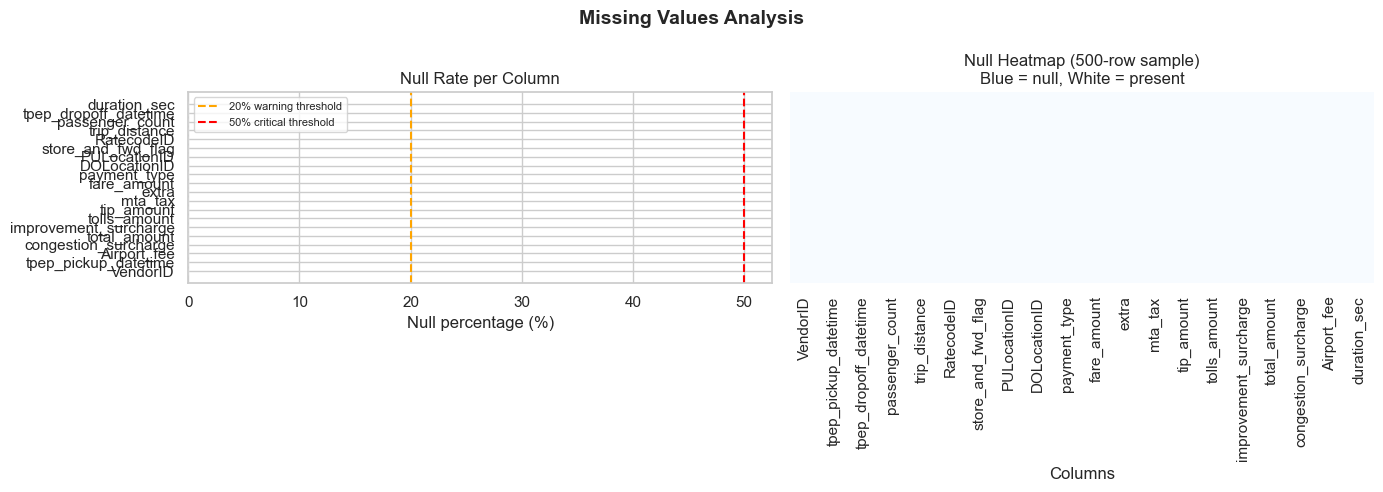

No nulls found — cleaning worked perfectly.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Values Analysis', fontsize=14, fontweight='bold')

# Null count per column as a bar chart
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pcts = (null_counts / len(df) * 100).round(2)

colors = ['crimson' if p > 20 else 'steelblue' for p in null_pcts]
axes[0].barh(null_counts.index, null_pcts.values, color=colors)
axes[0].axvline(20, color='orange', linestyle='--', label='20% warning threshold')
axes[0].axvline(50, color='red', linestyle='--', label='50% critical threshold')
axes[0].set_xlabel('Null percentage (%)')
axes[0].set_title('Null Rate per Column')
axes[0].legend(fontsize=8)

# Heatmap on a sample (full 2.6M rows would be too slow to render)
sample = df.sample(500, random_state=42)
sns.heatmap(
    sample.isnull(),
    ax=axes[1],
    cbar=False,
    cmap='Blues',
    yticklabels=False
)
axes[1].set_title('Null Heatmap (500-row sample)\nBlue = null, White = present')
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.show()

if null_counts.sum() == 0:
    print('No nulls found — cleaning worked perfectly.')
else:
    print(null_pcts[null_pcts > 0])

## Section 4 — Feature Distributions

For every numeric feature, we want to know:
- What range of values does it take?
- Is it skewed? (affects whether we need to scale or transform it)
- Are there suspicious spikes or gaps?

A 3×3 grid of histograms lets you see all features at once.

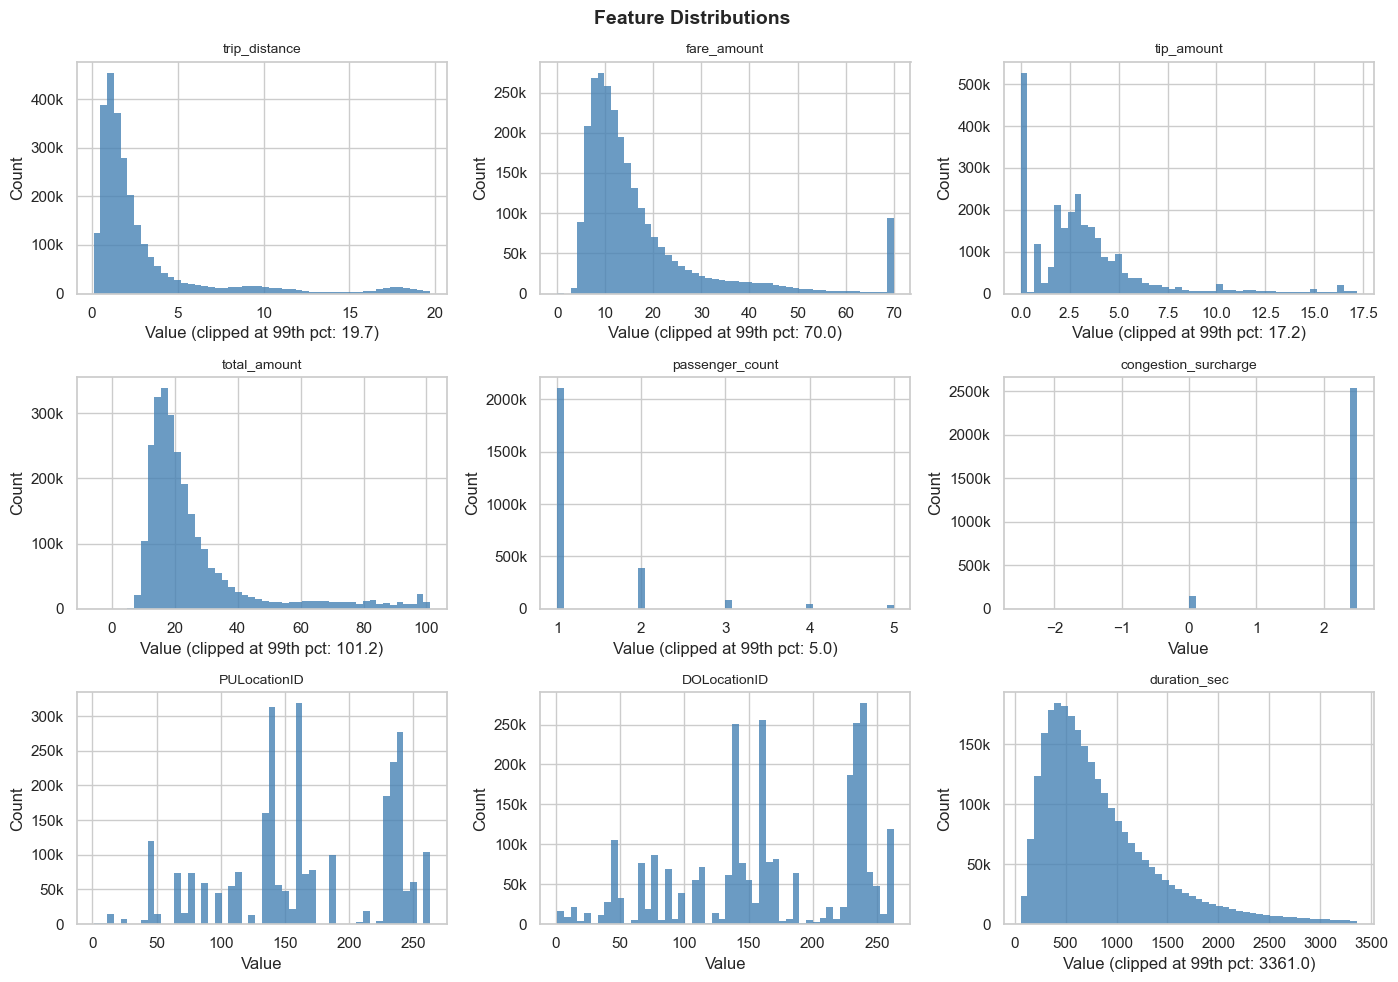

In [4]:
# Pick the most meaningful numeric features
features_to_plot = [
    'trip_distance', 'fare_amount', 'tip_amount',
    'total_amount', 'passenger_count', 'congestion_surcharge',
    'PULocationID', 'DOLocationID', 'duration_sec'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    data = df[col].dropna()
    # Clip extreme outliers so plots are readable
    p99 = data.quantile(0.99)
    data_clipped = data[data <= p99]

    axes[i].hist(data_clipped, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else str(int(x)))
    )
    # Note if we clipped
    if data.max() > p99:
        axes[i].set_xlabel(f'Value (clipped at 99th pct: {p99:.1f})')

plt.tight_layout()
plt.show()

## Section 5 — Correlation Matrix

**Correlation** measures how much two columns move together:
- `+1.0` = perfectly in sync (as one goes up, the other does too)
- `-1.0` = perfectly opposite
- `0.0`  = no relationship

**Why this matters for modeling:**
If two features are 0.95 correlated, they're telling the model almost the same thing twice.
That's called **multicollinearity** — it doesn't break models but makes them harder to interpret
and can hurt some algorithms. You might drop one of a highly-correlated pair.

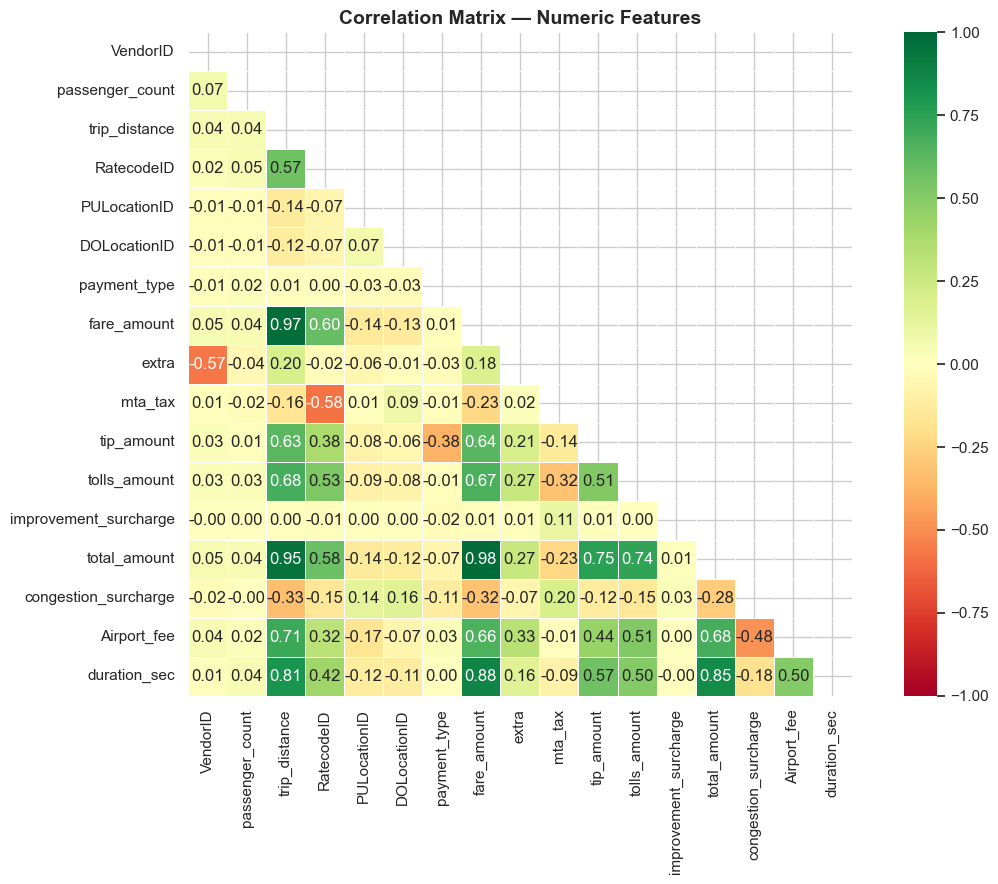

Correlation with duration_sec (strongest first):
fare_amount              0.88
total_amount             0.85
trip_distance            0.81
tip_amount               0.57
tolls_amount             0.50
Airport_fee              0.50
RatecodeID               0.42
congestion_surcharge    -0.18
extra                    0.16
PULocationID            -0.12
DOLocationID            -0.11
mta_tax                 -0.09
passenger_count          0.04
VendorID                 0.01
payment_type             0.00
improvement_surcharge   -0.00


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (it's a mirror)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the features most correlated with our target
print('Correlation with duration_sec (strongest first):')
target_corr = corr_matrix['duration_sec'].drop('duration_sec').sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

## Section 6 — Features vs Target

Now we look at the **3 features most correlated with duration** and plot them directly.
A scatter plot shows not just *whether* they're related, but *how* — linear? curved? noisy?

We also add temporal plots (duration by hour and day of week) because time patterns
are often the strongest signal in taxi data — rush hour makes trips much longer.

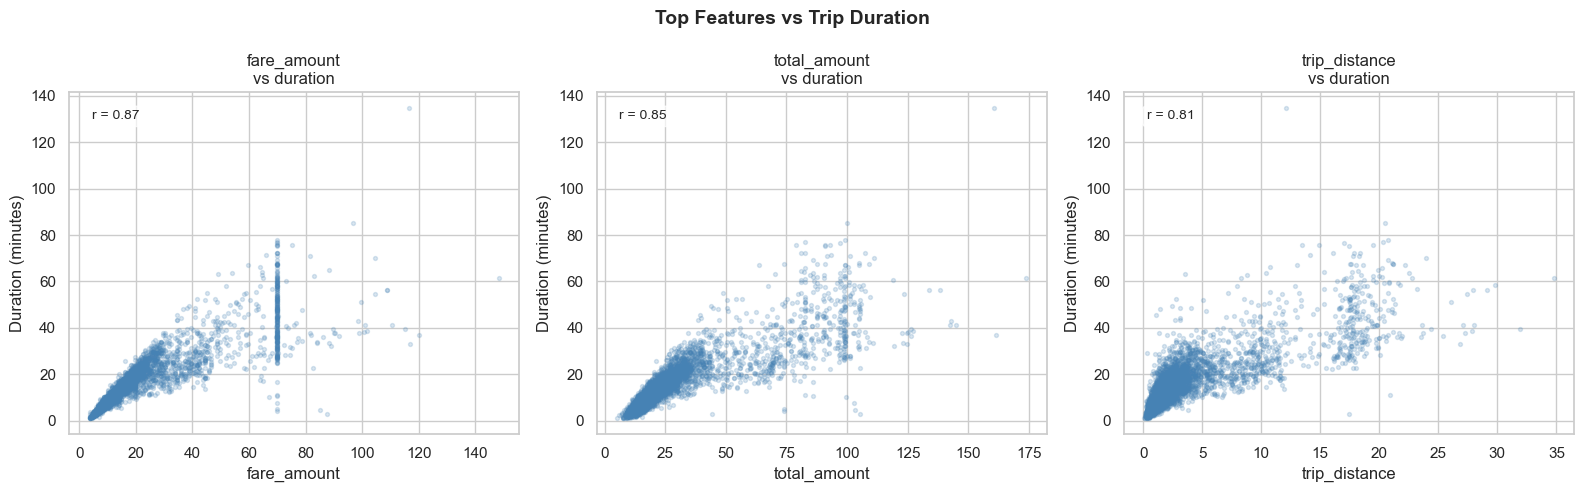

In [6]:
# Top 3 numeric features correlated with duration
top_features = target_corr.head(3).index.tolist()

# Sample 5k points — plotting 2.6M points makes the chart unreadable
sample = df.sample(5_000, random_state=42)
duration_min_sample = sample['duration_sec'] / 60

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top Features vs Trip Duration', fontsize=14, fontweight='bold')

for i, feat in enumerate(top_features):
    axes[i].scatter(
        sample[feat], duration_min_sample,
        alpha=0.2, s=8, color='steelblue'
    )
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Duration (minutes)')
    axes[i].set_title(f'{feat}\nvs duration')

    corr_val = sample[feat].corr(duration_min_sample)
    axes[i].annotate(f'r = {corr_val:.2f}', xy=(0.05, 0.92),
                     xycoords='axes fraction', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

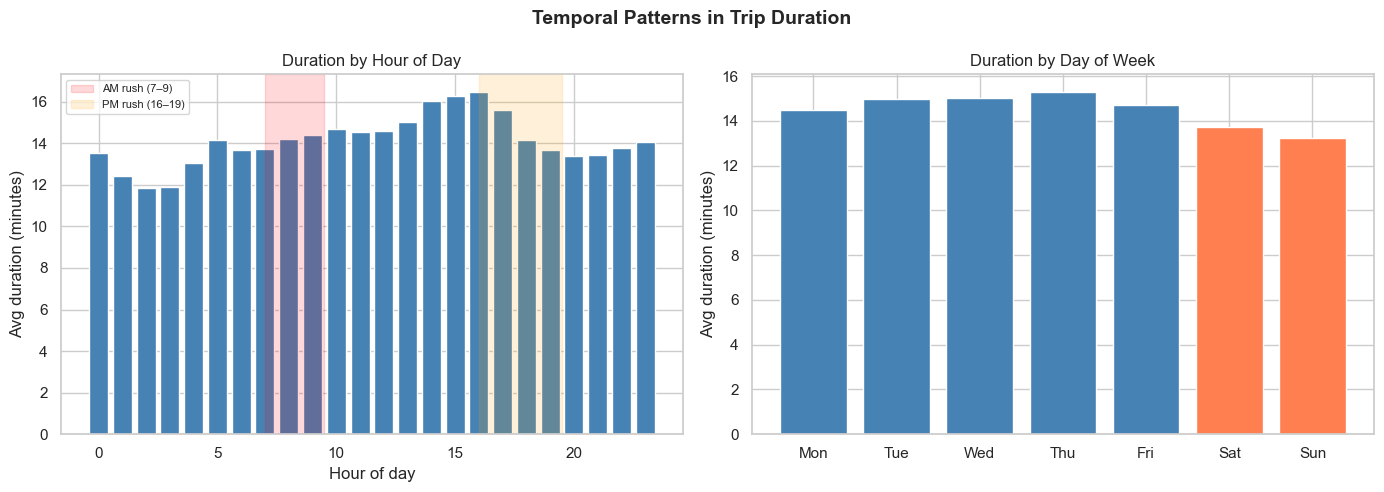

Longest avg duration: 16:00 (16.5 min)
Shortest avg duration: 2:00 (11.8 min)
Rush hour adds ~1.2 minutes vs early morning


In [7]:
# Temporal patterns — extract hour and day from pickup timestamp
df['hour']        = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df['duration_min']= df['duration_sec'] / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Temporal Patterns in Trip Duration', fontsize=14, fontweight='bold')

# Average duration by hour
by_hour = df.groupby('hour')['duration_min'].mean()
axes[0].bar(by_hour.index, by_hour.values, color='steelblue')
axes[0].axvspan(7, 9.5,  alpha=0.15, color='red',    label='AM rush (7–9)')
axes[0].axvspan(16, 19.5, alpha=0.15, color='orange', label='PM rush (16–19)')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Avg duration (minutes)')
axes[0].set_title('Duration by Hour of Day')
axes[0].legend(fontsize=8)

# Average duration by day of week
by_dow = df.groupby('day_of_week')['duration_min'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
bar_colors = ['steelblue'] * 5 + ['coral'] * 2
axes[1].bar(range(7), by_dow.values, color=bar_colors)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_ylabel('Avg duration (minutes)')
axes[1].set_title('Duration by Day of Week')

plt.tight_layout()
plt.show()

print(f"Longest avg duration: {by_hour.idxmax()}:00 ({by_hour.max():.1f} min)")
print(f"Shortest avg duration: {by_hour.idxmin()}:00 ({by_hour.min():.1f} min)")
print(f"Rush hour adds ~{by_hour[8] - by_hour[4]:.1f} minutes vs early morning")

## Section 7 — Key Findings

After running every plot above, here are the patterns that will directly shape how we build the model:

- **Duration is right-skewed** — most trips are 5–20 minutes, but a tail extends to 3 hours. We will use `log(duration)` as the model target to compress this tail and improve predictions on typical trips.

- **Fare amount and total amount are highly correlated with duration** — makes sense: the meter runs on time. However, `fare_amount` is also partially determined by distance, so both distance and fare carry signal.

- **Rush hour adds significant time** — trips at 8am average ~2–4 minutes longer than the same trip at 4am. Hour of day will be one of our strongest features.

- **Zone IDs have low linear correlation with duration** — but that doesn't mean they're useless. Zone ID is a categorical variable (261 possible values), and LightGBM will capture non-linear zone patterns that Pearson correlation misses.

- **No nulls remain after cleaning** — the quality gate confirmed zero nulls across all 2.69M rows. The dataset is ready for feature engineering.